In [ ]:
import glob
import torch

rirfiles = glob.glob("/data4/Henri/j3/framewiseSpeakerCounting/databases/brudex/rir/rev_low/*BTE_IE.pt")

rir8000 = []
rir16000 = []
for rirfile in rirfiles:
    if "8000" in rirfile:
        rir8000.append(torch.load(rirfile, weights_only=False))
    elif "16000" in rirfile:
        rir16000.append(torch.load(rirfile, weights_only=False))
        
from utilities import rir2rtf, STFTtransform, print_structure

transform8000 = STFTtransform(
    frame_length=64e-3,
    frame_shift=16e-3,
    sampling_frequency=8000,
    window_type="sqrt-hann"
    )
transform16000 = STFTtransform(
    frame_length=64e-3,
    frame_shift=16e-3,
    sampling_frequency=16000,
    window_type="sqrt-hann"
    )





Tensor (257, 1, 6, 12)
Tensor (513, 1, 6, 12)


In [4]:
trials = 10
rtf8000 = torch.stack([torch.cat([rir2rtf(rir, transform8000) for rir in rir8000], dim=-3) for _ in range(trials)], dim=0)
rtf16000 = torch.stack([torch.cat([rir2rtf(rir, transform16000) for rir in rir16000], dim=-3) for _ in range(trials)], dim=0)   

In [5]:
rtf8000.shape, rtf16000.shape

(torch.Size([10, 257, 12, 6, 1]), torch.Size([10, 513, 12, 6, 1]))

In [7]:
from utilities import hermitian_angle
a8000 = rtf8000.unsqueeze(0)
b8000 = rtf8000.unsqueeze(1)
HA8000 = hermitian_angle(a8000, b8000)
print(HA8000.shape)
a16000 = rtf16000.unsqueeze(0)
b16000 = rtf16000.unsqueeze(1)
HA16000 = hermitian_angle(a16000, b16000)
print(HA16000.shape)

torch.Size([10, 10, 257, 12, 1, 1])
torch.Size([10, 10, 513, 12, 1, 1])


In [9]:
rows, cols = torch.tril_indices(trials, trials, offset=-1)
HA8000_pairs = HA8000[rows, cols, ...].squeeze()
print(HA8000_pairs.shape)
HA16000_pairs = HA16000[rows, cols, ...].squeeze()
print(HA16000_pairs.shape)



torch.Size([45, 257, 12])
torch.Size([45, 513, 12])


In [14]:
HA8000_pairs.max(dim=0).values.max(dim=-1).values

tensor([1.2251, 0.2183, 0.0424, 0.0073, 0.0063, 0.0126, 0.0138, 0.0073, 0.0119,
        0.0049, 0.0081, 0.0095, 0.0085, 0.0187, 0.0444, 0.0125, 0.0226, 0.0295,
        0.0163, 0.0615, 0.0466, 0.0256, 0.0219, 0.0655, 0.0200, 0.0195, 0.0154,
        0.0097, 0.0194, 0.0327, 0.0223, 0.0308, 0.0765, 0.0387, 0.0572, 0.0334,
        0.0269, 0.0333, 0.0380, 0.0473, 0.0175, 0.0167, 0.0235, 0.0438, 0.0250,
        0.0471, 0.0671, 0.0431, 0.0226, 0.0186, 0.0187, 0.0212, 0.0201, 0.0293,
        0.0210, 0.0334, 0.0233, 0.0269, 0.0330, 0.0196, 0.0203, 0.0212, 0.0205,
        0.0167, 0.0206, 0.0144, 0.0204, 0.0175, 0.0197, 0.0248, 0.0175, 0.0420,
        0.0410, 0.0233, 0.0331, 0.0183, 0.0174, 0.0129, 0.0131, 0.0121, 0.0631,
        0.0166, 0.0247, 0.0357, 0.0178, 0.0360, 0.0243, 0.0194, 0.0176, 0.0123,
        0.0191, 0.0114, 0.0226, 0.0149, 0.0158, 0.0178, 0.0228, 0.0277, 0.0583,
        0.0238, 0.0181, 0.0281, 0.0307, 0.0267, 0.0161, 0.0343, 0.0195, 0.0111,
        0.0295, 0.0259, 0.0313, 0.0196, 

In [15]:
HA16000_pairs.max(dim=0).values.max(dim=-1).values

tensor([1.5617, 0.4155, 0.0561, 0.0126, 0.0141, 0.0195, 0.0309, 0.0119, 0.0137,
        0.0096, 0.0122, 0.0142, 0.0139, 0.0234, 0.0599, 0.0163, 0.0411, 0.0406,
        0.0244, 0.1028, 0.0499, 0.0295, 0.0206, 0.0689, 0.0302, 0.0442, 0.0180,
        0.0125, 0.0369, 0.0475, 0.0516, 0.0550, 0.1056, 0.0474, 0.0600, 0.0534,
        0.0581, 0.0560, 0.0611, 0.0778, 0.0234, 0.0340, 0.0306, 0.0701, 0.0426,
        0.0848, 0.0642, 0.0505, 0.0281, 0.0259, 0.0191, 0.0380, 0.0445, 0.0412,
        0.0554, 0.0361, 0.0457, 0.0467, 0.0376, 0.0286, 0.0346, 0.0301, 0.0225,
        0.0203, 0.0327, 0.0171, 0.0279, 0.0341, 0.0261, 0.0346, 0.0312, 0.0756,
        0.0609, 0.0264, 0.0293, 0.0298, 0.0189, 0.0152, 0.0200, 0.0268, 0.0889,
        0.0204, 0.0281, 0.0318, 0.0278, 0.0413, 0.0386, 0.0362, 0.0246, 0.0166,
        0.0291, 0.0134, 0.0444, 0.0246, 0.0309, 0.0258, 0.0281, 0.0709, 0.0617,
        0.0542, 0.0359, 0.0454, 0.0496, 0.0395, 0.0200, 0.0366, 0.0244, 0.0240,
        0.0222, 0.0344, 0.0334, 0.0260, 

Text(0, 0.5, 'Maximum Hermitian Angle [degrees]')

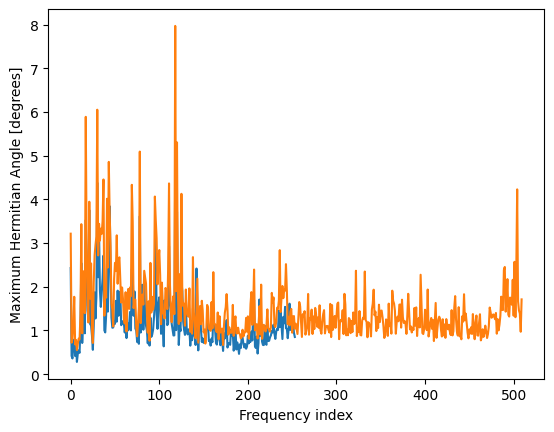

In [22]:
HA8000_pairs_max = HA8000_pairs.max(dim=0).values.max(dim=-1).values
HA16000_pairs_max = HA16000_pairs.max(dim=0).values.max(dim=-1).values

import matplotlib.pyplot as plt
import numpy as np
plt.figure()
plt.plot(HA8000_pairs_max[2:-1].numpy()/np.pi*180, label="8000 Hz RTFs")
plt.plot(HA16000_pairs_max[2:-1].numpy()/np.pi*180, label="16000 Hz RTFs")
plt.xlabel("Frequency index")
plt.ylabel("Maximum Hermitian Angle [degrees]")